### Import Libraries and Dataset

In [114]:
# !pip3 install -U ucimlrepo

from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [115]:
# import dataset
dry_bean = fetch_ucirepo(id=602)

# DataFrame of feature and target columns
df = dry_bean.data.original.copy()

## Data Understanding

In [116]:
df.shape

(13611, 17)

The shape of the dataset is (13611, 17) , containing 16 Features beside (Y / Bean Class)

In [117]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

All columns (features) are numerical except "Class" column which will be our target.

## Data Cleaning

In [119]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

There are no NULL values in the data

In [120]:
df.duplicated().sum()

np.int64(68)

In [121]:
df[df.duplicated(keep=False)]

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5504,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5508,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5547,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7285,63948,996.497,412.297178,198.877557,2.073121,0.875971,64641,285.343867,0.777909,0.989279,0.809254,0.692083,0.006447,0.000912,0.478979,0.992981,HOROZ
7339,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ
7340,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ
7341,65781,1039.257,409.713859,204.992832,1.998674,0.865834,66762,289.404510,0.642549,0.985306,0.765358,0.706358,0.006228,0.000956,0.498941,0.997221,HOROZ


In [122]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

In [123]:
df.shape

(13543, 17)

## Exploratory Data Analysis — EDA

In [124]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,53048.460385,854.993406,319.895602,202.365321,1.581075,0.750315,53767.986709,253.034094,0.749829,0.987152,0.873671,0.800352,0.006561,0.001719,0.644341,0.995078
std,29392.438324,214.722684,85.809260,45.051632,0.245245,0.091858,29844.248525,59.307709,0.048939,0.004650,0.059393,0.061464,0.001130,0.000595,0.098653,0.004347
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


By looking at the description of the data we can come to the conclusion that our data will need standardization.

### Target Info

In [125]:
print(df['Class'].unique())

<ArrowStringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str


In [126]:
print(df['Class'].value_counts())

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [127]:
class_percentages = df['Class'].value_counts(normalize=True) * 100
print(class_percentages)

Class
DERMASON    26.183268
SIRA        19.463930
SEKER       14.967142
HOROZ       13.734032
CALI        12.035738
BARBUNYA     9.761500
BOMBAY       3.854390
Name: proportion, dtype: float64


There are 7 unique types of beans in "Class" Column

*   BOMBAY occurs the least amount of times in dataset
*   DERMASON most often appears in our dataset

### Data Visualization

#### Class Distribution

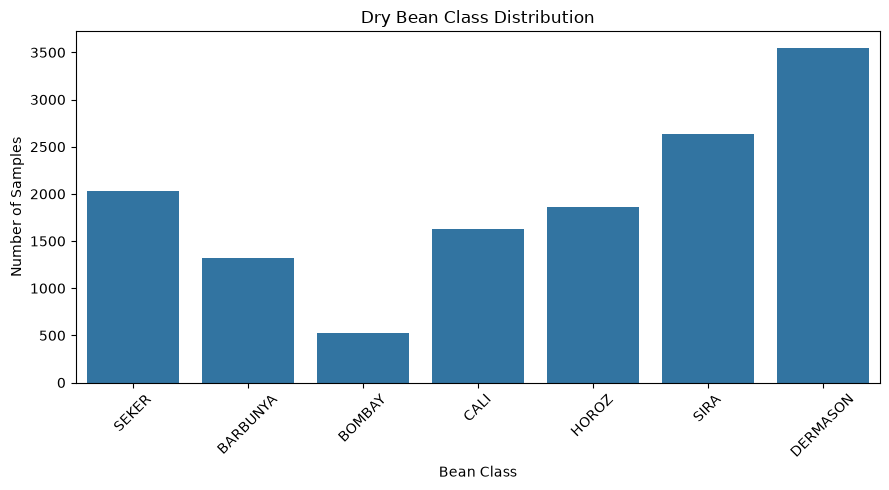

In [128]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Class')
plt.title('Dry Bean Class Distribution')
plt.xlabel('Bean Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Feature Distribution

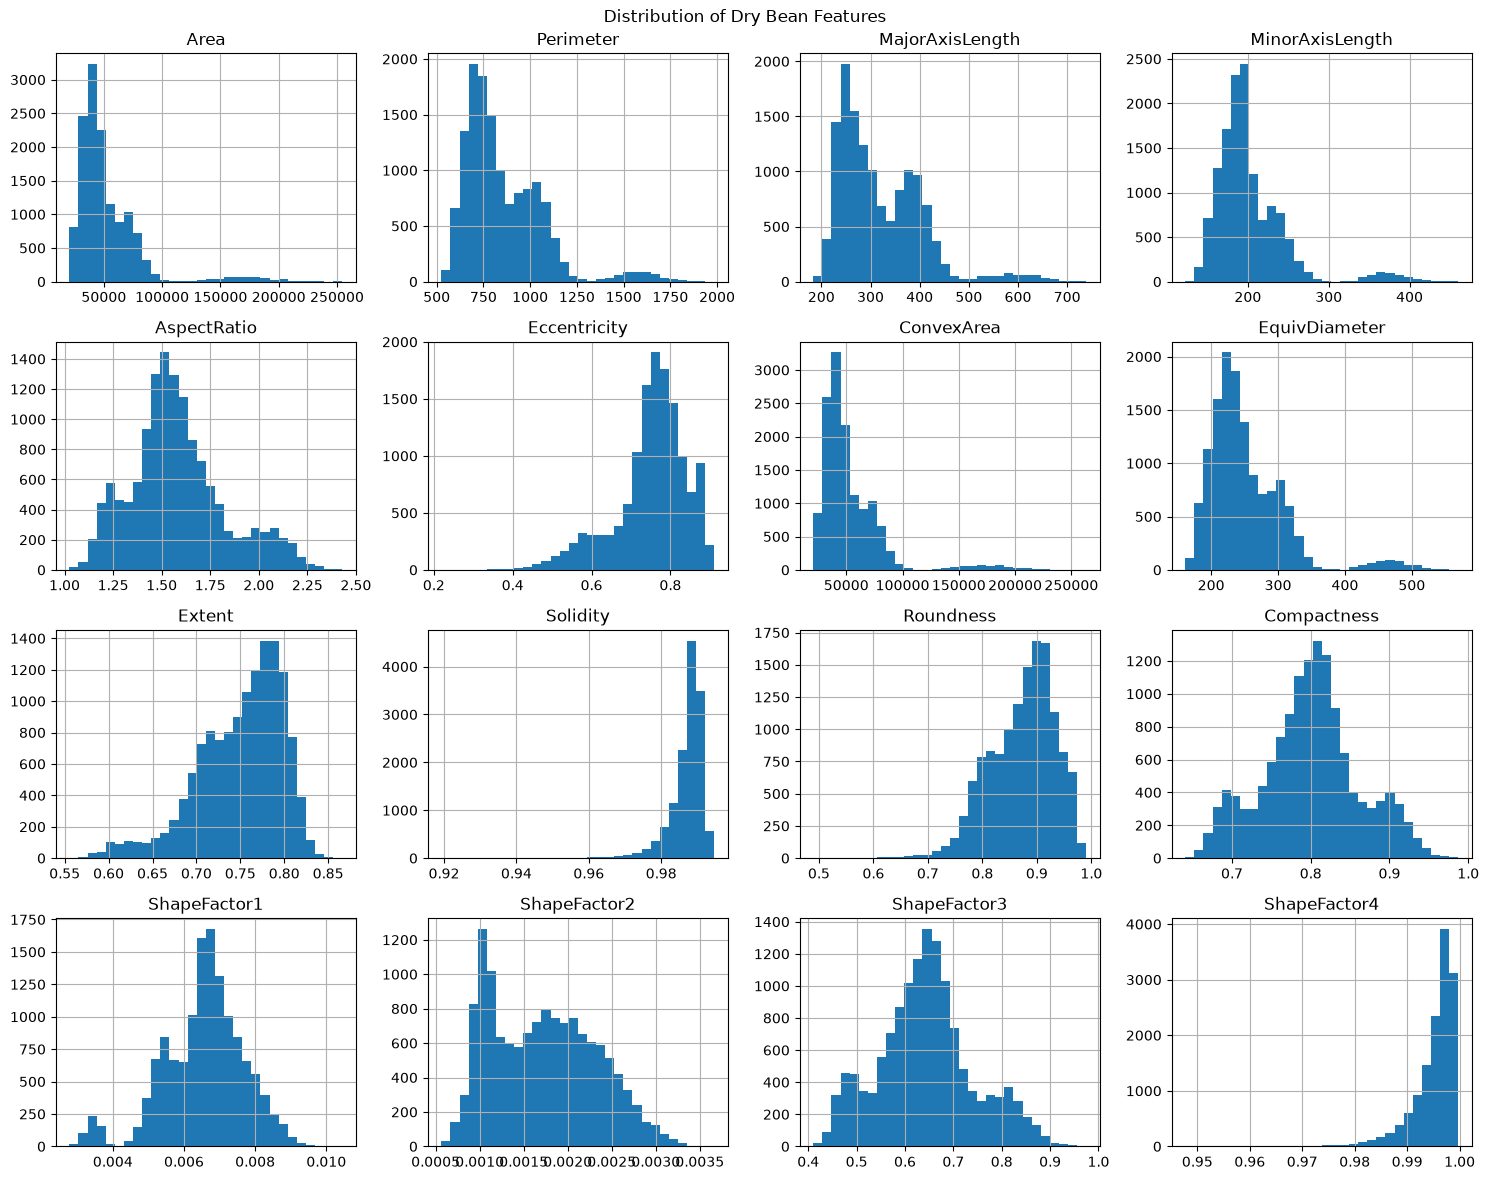

In [129]:
df.hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Dry Bean Features")
plt.tight_layout()
plt.show()

#### Feature Correlation Matrix

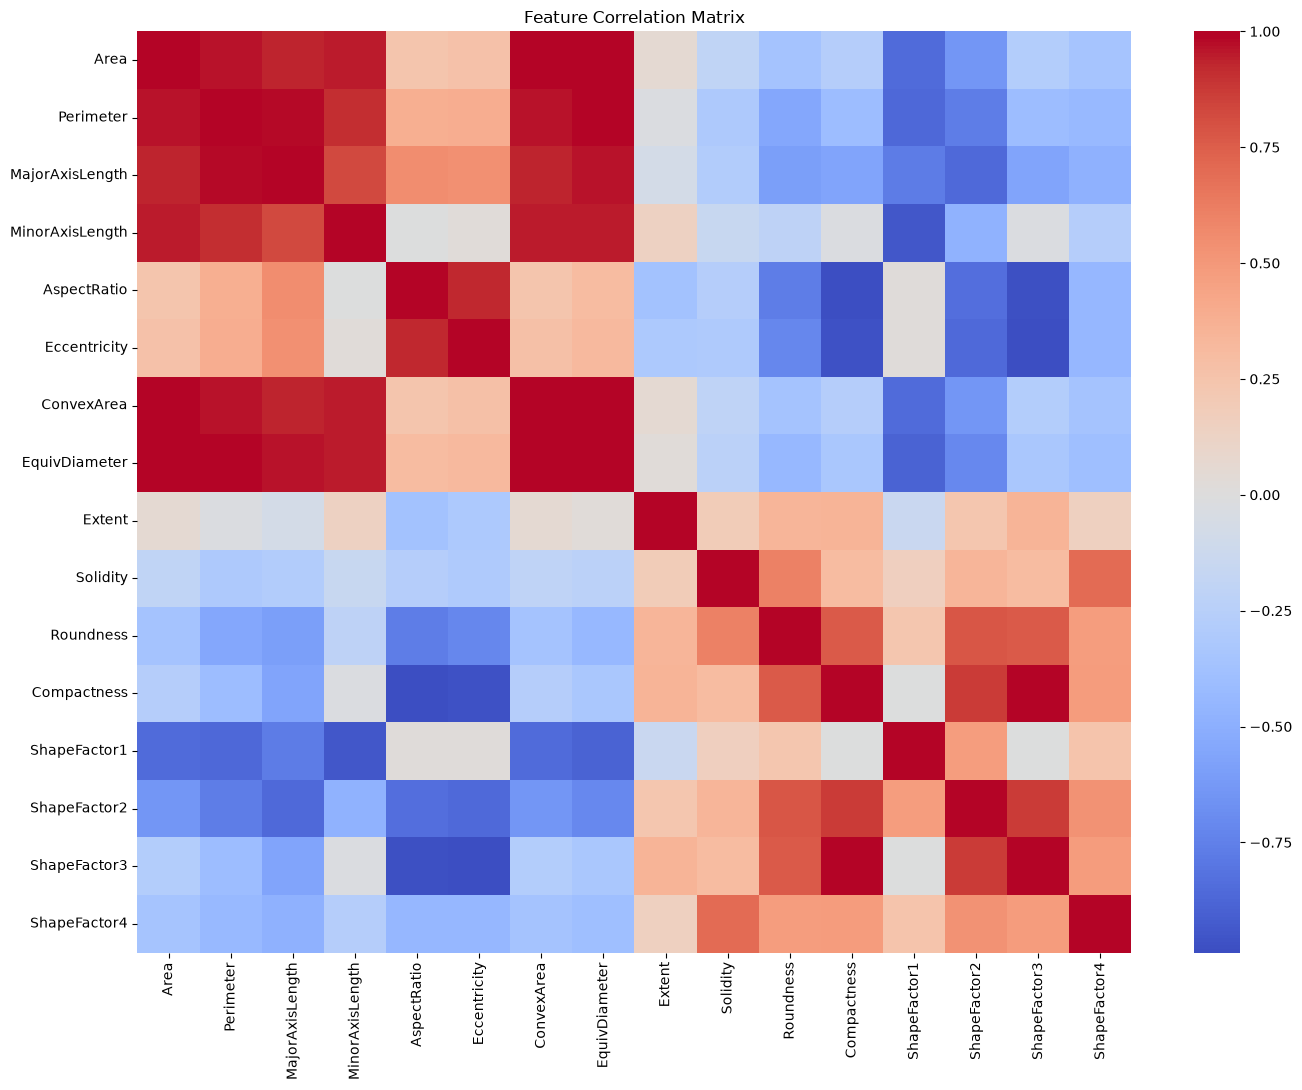

In [130]:
plt.figure(figsize=(14, 11))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

#### Class and Feature Boxplots

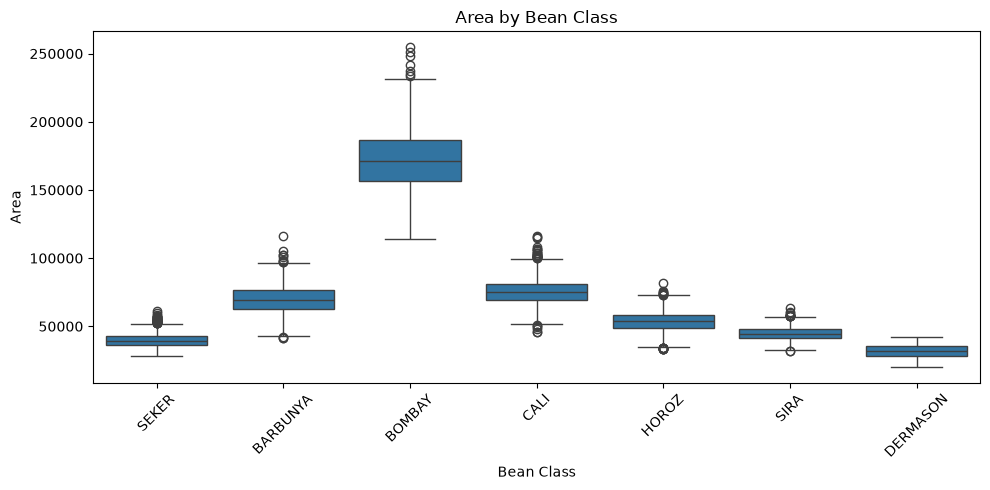

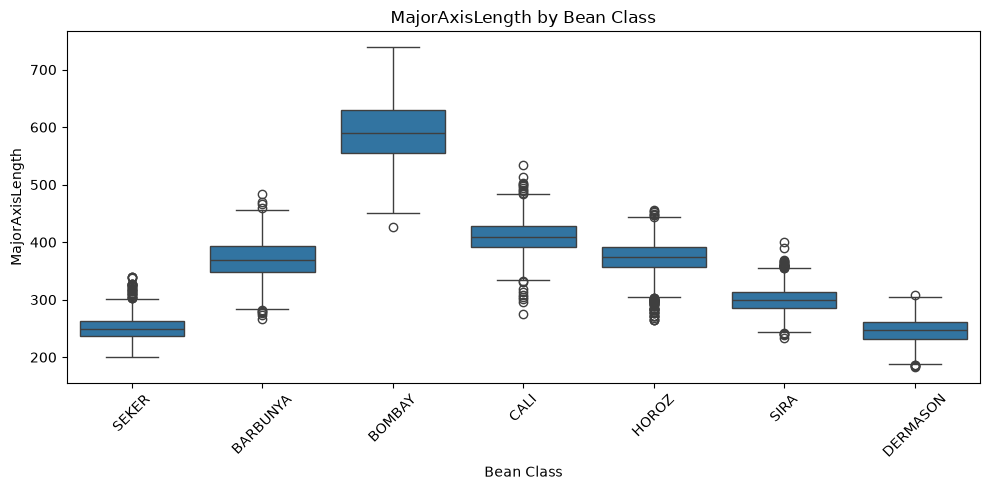

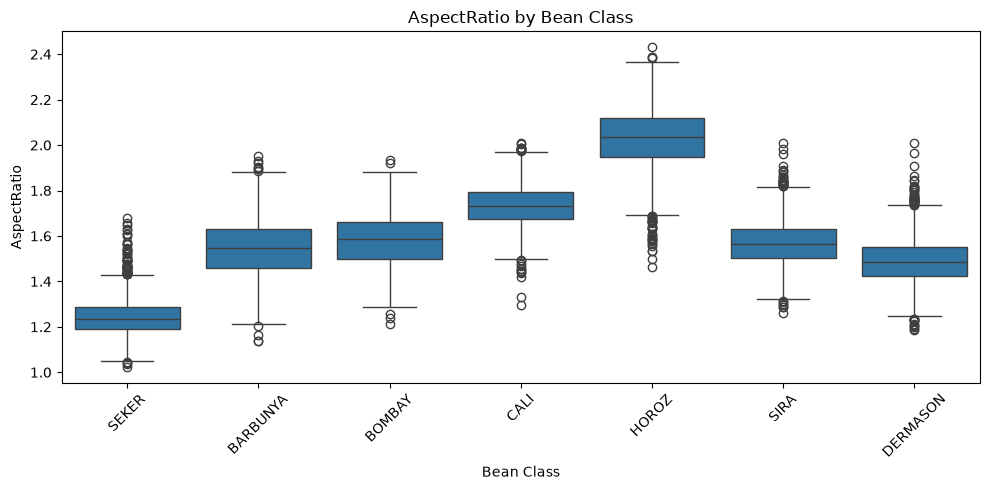

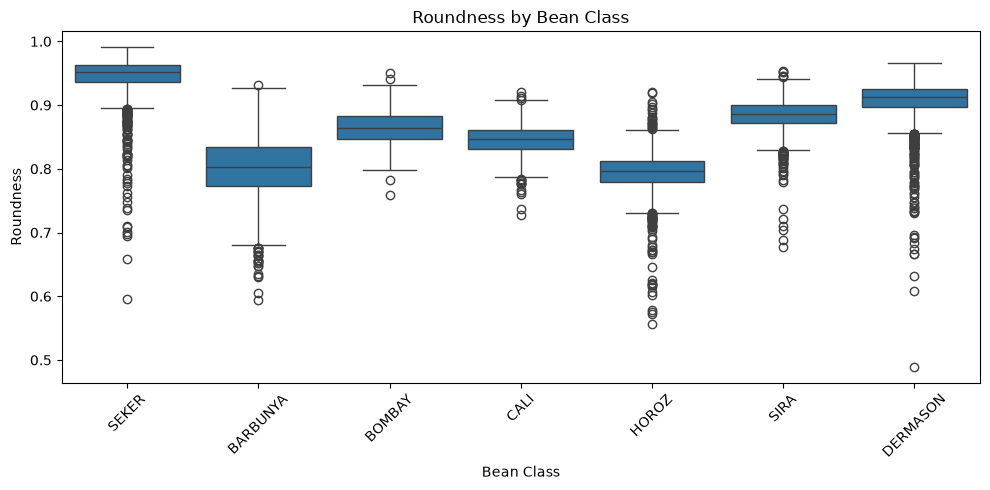

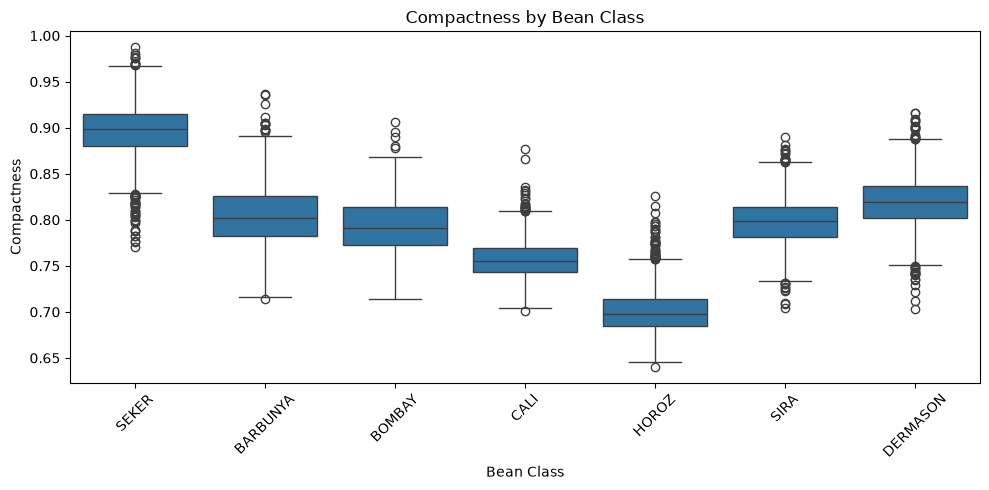

In [131]:
selected_features = [
    "Area",
    "MajorAxisLength",
    "AspectRatio",
    "Roundness",
    "Compactness"
]

for feature in selected_features:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=df,
        x="Class",
        y=feature
    )

    plt.title(f"{feature} by Bean Class")
    plt.xlabel("Bean Class")
    plt.ylabel(feature)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

#### Scatter plots colored by Class

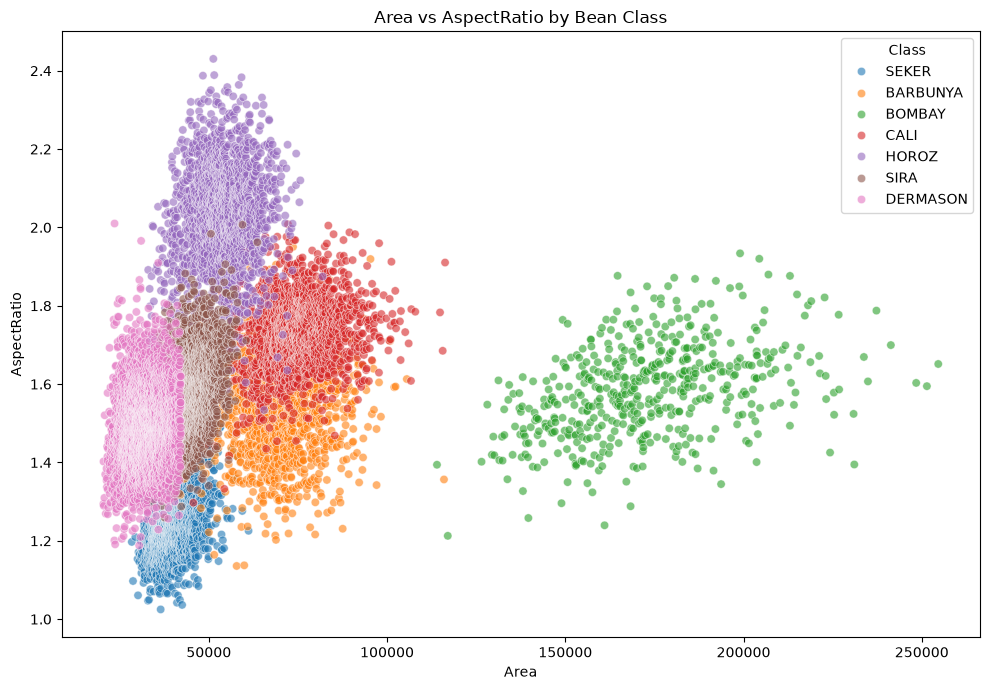

In [132]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Area",
    y="AspectRatio",
    hue="Class",
    alpha=0.6
)

plt.title("Area vs AspectRatio by Bean Class")
plt.tight_layout()
plt.show()

- Area tells you about overall size
- AspectRatio tells you about elongation / shape
- So one axis is mostly size, the other is shape.
- That gives the scatter plot a better chance of separating classes that overlap in size but differ in shape.

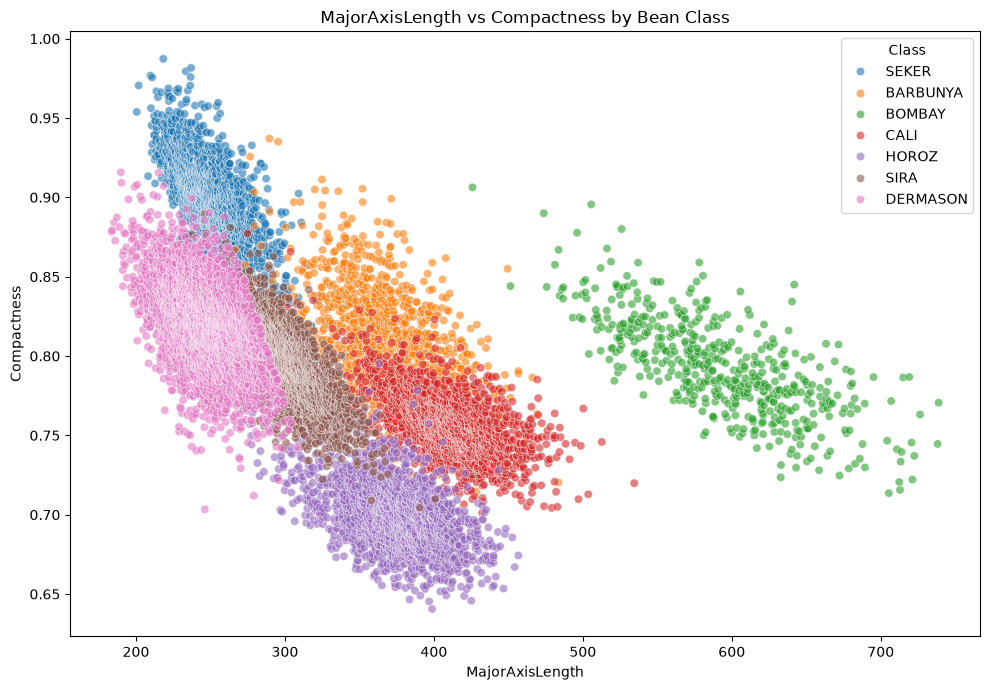

In [133]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="MajorAxisLength",
    y="Compactness",
    hue="Class",
    alpha=0.6
)

plt.title("MajorAxisLength vs Compactness by Bean Class")
plt.tight_layout()
plt.show()

For MajorAxisLength vs Compactness:
- MajorAxisLength measures length
- Compactness measures how compact/rounded the shape is
- This is useful because two beans may have similar lengths but different shapes. 
- So the combination can potentially separate classes better than either feature alone.

## Define Features X and Target y

In [134]:
X = df.drop(columns="Class")
y = df["Class"]

## Data Splitting

In [135]:
from sklearn.model_selection import train_test_split

# First: 80% train + validation, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [136]:
# Second: split the 80% into 60% train and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

In [137]:
total = len(X)

print(f"Train: {len(X_train) / total * 100:.2f}%")
print(f"Validation: {len(X_val) / total * 100:.2f}%")
print(f"Test: {len(X_test) / total * 100:.2f}%")

Train: 59.99%
Validation: 20.00%
Test: 20.00%


In [138]:
distribution = pd.DataFrame({
    "Original": y.value_counts(normalize=True) * 100,
    "Train": y_train.value_counts(normalize=True) * 100,
    "Validation": y_val.value_counts(normalize=True) * 100,
    "Test": y_test.value_counts(normalize=True) * 100
})

print(distribution.round(2))

          Original  Train  Validation   Test
Class                                       
DERMASON     26.18  26.18       26.21  26.17
SIRA         19.46  19.47       19.45  19.45
SEKER        14.97  14.97       14.95  14.99
HOROZ        13.73  13.74       13.73  13.73
CALI         12.04  12.04       12.03  12.03
BARBUNYA      9.76   9.76        9.75   9.78
BOMBAY        3.85   3.85        3.88   3.84


## Feature Engineering

**Feature Engineering / Preprocessing**

This is an important stage.
Feature engineering means changing or creating features to make them more useful to the model.

In [139]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# learn the scaling values from training data, then transform it.
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
# use the same values learned from training data to transform the test data.
X_test_scaled = scaler.transform(X_test)

## Model Training

In [140]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")

    return accuracy, macro_f1

### Dummy Classifier

In [141]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_val)

dummy_acc, dummy_f1 = evaluate_model(y_val, y_pred_dummy)

Accuracy: 0.2621
Macro-F1: 0.0593


### Logistic Regression

In [142]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_pred = logreg.predict(X_val_scaled)

logreg_acc, logreg_f1 = evaluate_model(y_val, logreg_pred)

Accuracy: 0.9406
Macro-F1: 0.9501


### Random Forest

In [143]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)

rf_acc, rf_f1 = evaluate_model(y_val, rf_pred)

Accuracy: 0.9328
Macro-F1: 0.9435


### PyTorch MLP

In [144]:
# Encode the class names
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

In [145]:
for i, name in enumerate(label_encoder.classes_):
    print(i, name)

0 BARBUNYA
1 BOMBAY
2 CALI
3 DERMASON
4 HOROZ
5 SEKER
6 SIRA


In [146]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [147]:
torch.manual_seed(42)
np.random.seed(42)

In [148]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_encoded,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_encoded,
    dtype=torch.long
)

**Create mini-batches**

Instead of sending all ~8,000 training samples through the network at once, divide them into batches.

In [149]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [150]:
class BeanMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(16, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 7)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)

        return x

In [151]:
model = BeanMLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [152]:
epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ==========================
    # TRAINING
    # ==========================

    model.train()

    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        # 1. Reset old gradients
        optimizer.zero_grad()

        # 2. Forward pass
        predictions = model(X_batch)

        # 3. Calculate loss
        loss = criterion(
            predictions,
            y_batch
        )

        # 4. Backpropagation
        loss.backward()

        # 5. Update model weights
        optimizer.step()

        total_train_loss += (
            loss.item() * X_batch.size(0)
        )

    average_train_loss = (
        total_train_loss / len(train_dataset)
    )

    train_losses.append(
        average_train_loss
    )

    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    with torch.no_grad():

        val_predictions = model(
            X_val_tensor
        )

        val_loss = criterion(
            val_predictions,
            y_val_tensor
        )

    val_losses.append(
        val_loss.item()
    )

    # Print progress
    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Validation Loss: {val_loss.item():.4f}"
        )

Epoch  10/100 | Train Loss: 0.1986 | Validation Loss: 0.1806
Epoch  20/100 | Train Loss: 0.1857 | Validation Loss: 0.1774
Epoch  30/100 | Train Loss: 0.1806 | Validation Loss: 0.1723
Epoch  40/100 | Train Loss: 0.1767 | Validation Loss: 0.1709
Epoch  50/100 | Train Loss: 0.1707 | Validation Loss: 0.1727
Epoch  60/100 | Train Loss: 0.1680 | Validation Loss: 0.1756
Epoch  70/100 | Train Loss: 0.1652 | Validation Loss: 0.1728
Epoch  80/100 | Train Loss: 0.1617 | Validation Loss: 0.1755
Epoch  90/100 | Train Loss: 0.1595 | Validation Loss: 0.1826
Epoch 100/100 | Train Loss: 0.1569 | Validation Loss: 0.1749


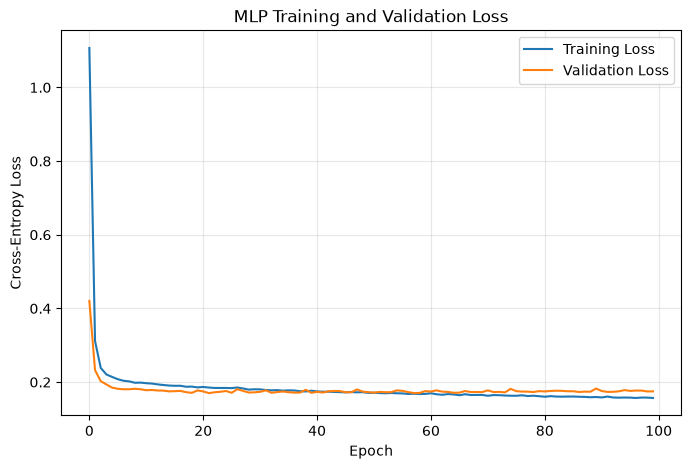

In [153]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("MLP Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [154]:
model.eval()

with torch.no_grad():

    outputs = model(X_val_tensor)

    predicted_classes = torch.argmax(
        outputs,
        dim=1
    )

In [155]:
mlp_acc, mlp_f1 = evaluate_model(
    y_val_encoded,
    predicted_classes.numpy()
)

Accuracy: 0.9384
Macro-F1: 0.9485


In [156]:
results = pd.DataFrame({
    "Model": [
        "Dummy",
        "Logistic Regression",
        "Random Forest",
        "MLP"
    ],

    "Accuracy": [
        dummy_acc,
        logreg_acc,
        rf_acc,
        mlp_acc
    ],

    "Macro-F1": [
        dummy_f1,
        logreg_f1,
        rf_f1,
        mlp_f1
    ]
})

results

,Model,Accuracy,Macro-F1
0,Dummy,0.262089,0.059332
1,Logistic Regression,0.940568,0.950059
2,Random Forest,0.932817,0.943533
3,MLP,0.938354,0.948451


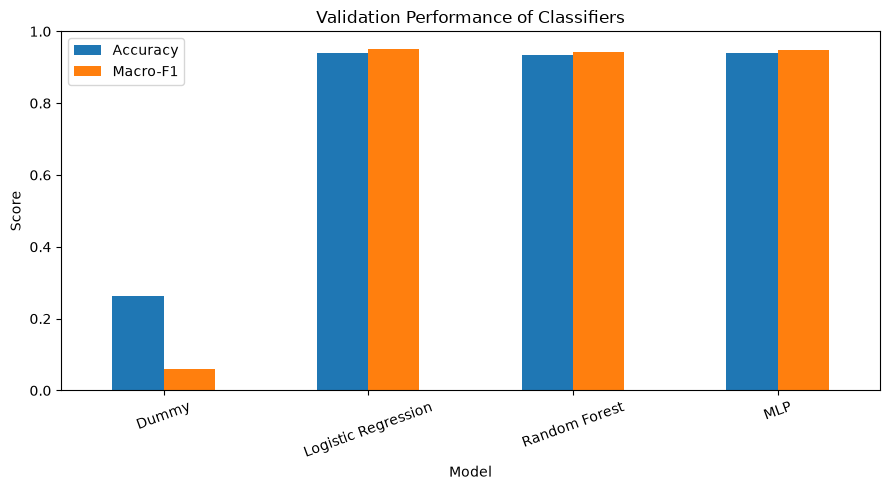

In [157]:
results_plot = results.set_index("Model")

results_plot[
    ["Accuracy", "Macro-F1"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Score")
plt.title("Validation Performance of Classifiers")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

plt.show()

Logistic Regression is highest

## Error Analysis

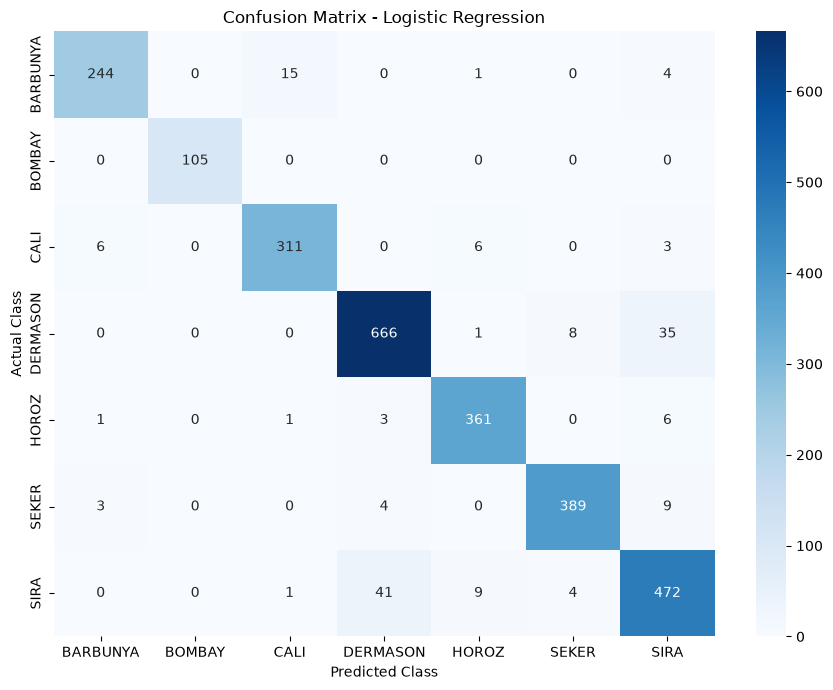

In [158]:
from sklearn.metrics import confusion_matrix

labels = sorted(y_val.unique())

cm = confusion_matrix(
    y_val,
    logreg_pred,
    labels=labels
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [159]:
confused_pairs = []

for i in range(len(labels)):
    for j in range(i + 1, len(labels)):

        errors = cm[i, j] + cm[j, i]

        confused_pairs.append(
            (
                labels[i],
                labels[j],
                errors
            )
        )

confused_pairs = sorted(
    confused_pairs,
    key=lambda x: x[2],
    reverse=True
)

for pair in confused_pairs[:5]:
    print(pair)

('DERMASON', 'SIRA', np.int64(76))
('BARBUNYA', 'CALI', np.int64(21))
('HOROZ', 'SIRA', np.int64(15))
('SEKER', 'SIRA', np.int64(13))
('DERMASON', 'SEKER', np.int64(12))


In [160]:
class_a = confused_pairs[0][0]
class_b = confused_pairs[0][1]

print("Most confused classes:")
print(class_a, "and", class_b)

Most confused classes:
DERMASON and SIRA


In [161]:
val_df = X_val.copy()

val_df["Class"] = y_val.values

pair_df = val_df[
    val_df["Class"].isin([class_a, class_b])
]

pair_df.shape

(1237, 17)

In [162]:
pair_df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
8521,43864,799.411,303.430174,184.354784,1.645903,0.794267,44336,236.324733,0.732776,0.989354,0.862537,0.778844,0.006918,0.001570,0.606598,0.998401,SIRA
7409,35570,710.530,263.260383,173.378732,1.518412,0.752508,36054,212.812431,0.789287,0.986576,0.885378,0.808372,0.007401,0.001950,0.653466,0.992231,SIRA
9022,46137,804.134,301.858498,195.156389,1.546752,0.762900,46601,242.370487,0.774111,0.990043,0.896607,0.802927,0.006543,0.001677,0.644693,0.997179,SIRA
7704,39610,747.285,286.768818,176.471271,1.625017,0.788232,40040,224.572969,0.743640,0.989261,0.891337,0.783115,0.007240,0.001680,0.613269,0.996573,SIRA
8813,45163,785.996,288.234367,200.130954,1.440229,0.719653,45618,239.798494,0.796273,0.990026,0.918654,0.831957,0.006382,0.001886,0.692152,0.996857,SIRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7580,38509,733.994,272.173897,180.771739,1.505622,0.747575,38979,221.429857,0.763295,0.987942,0.898229,0.813560,0.007068,0.001910,0.661880,0.996541,SIRA
13350,39857,755.392,283.623668,179.430885,1.580685,0.774448,40330,225.272077,0.692154,0.988272,0.877748,0.794264,0.007116,0.001747,0.630855,0.997183,DERMASON
10315,25895,592.636,217.882445,151.450689,1.438636,0.718910,26198,181.577912,0.724782,0.988434,0.926509,0.833376,0.008414,0.002504,0.694515,0.999154,DERMASON
11367,30431,635.556,233.011734,166.573328,1.398854,0.699256,30752,196.839916,0.793590,0.989562,0.946713,0.844764,0.007657,0.002405,0.713626,0.998259,DERMASON


In [163]:
feature_overlap = []

for feature in X_val.columns:

    values_a = pair_df[
        pair_df["Class"] == class_a
    ][feature]

    values_b = pair_df[
        pair_df["Class"] == class_b
    ][feature]

    mean_diff = abs(
        values_a.mean() - values_b.mean()
    )

    pooled_std = np.sqrt(
        (
            values_a.var() +
            values_b.var()
        ) / 2
    )

    separation = mean_diff / pooled_std

    feature_overlap.append(
        (feature, separation)
    )

feature_overlap = sorted(
    feature_overlap,
    key=lambda x: x[1]
)

feature_overlap_df = pd.DataFrame(
    feature_overlap,
    columns=["Feature", "Separation Score"]
)

feature_overlap_df

,Feature,Separation Score
0,Solidity,0.094092
1,Extent,0.125291
2,ShapeFactor4,0.633340
3,AspectRatio,0.919347
4,Eccentricity,0.919504
5,Compactness,0.948422
6,ShapeFactor3,0.949103
7,Roundness,0.988819
8,ShapeFactor2,1.957887
9,ShapeFactor1,2.158412


In [164]:
top_overlap_features = [
    item[0]
    for item in feature_overlap[:4]
]

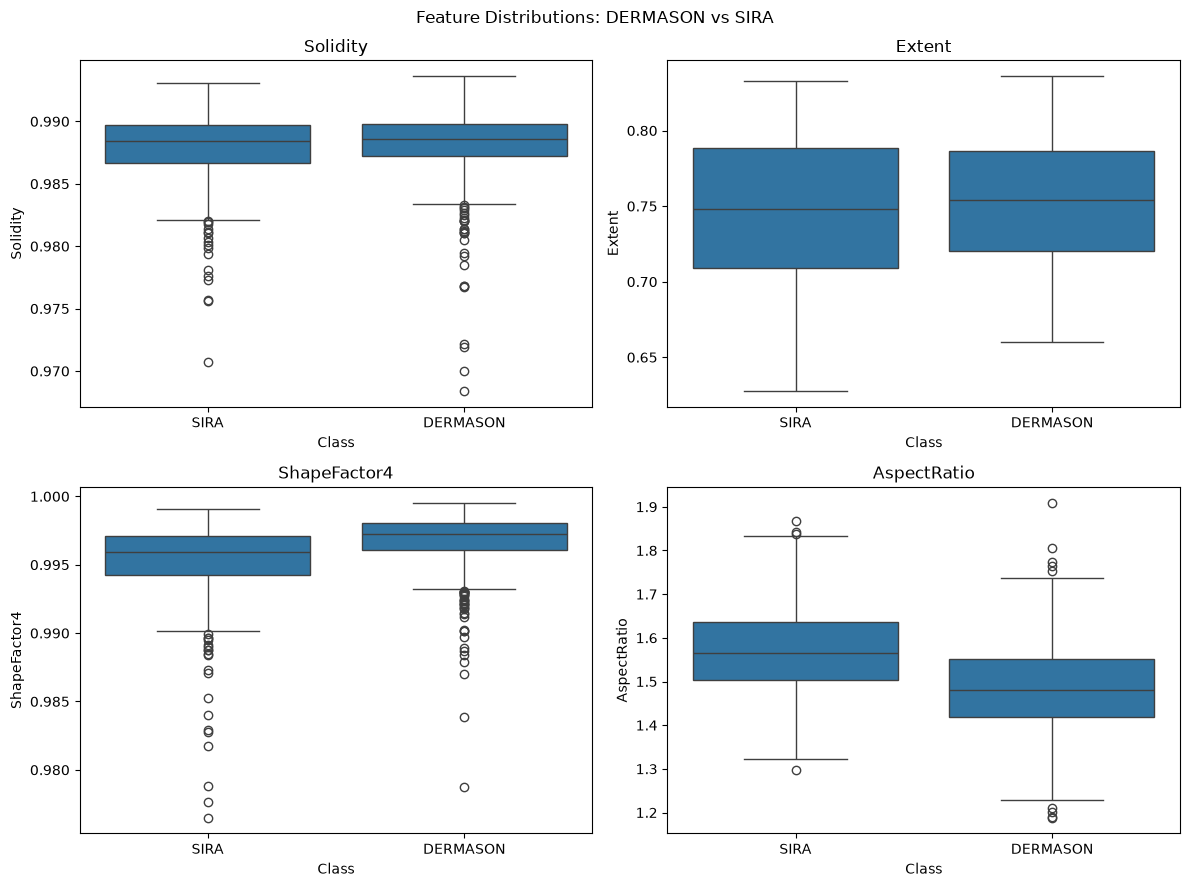

In [165]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for ax, feature in zip(
    axes,
    top_overlap_features
):

    sns.boxplot(
        data=pair_df,
        x="Class",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)

plt.suptitle(
    f"Feature Distributions: "
    f"{class_a} vs {class_b}"
)

plt.tight_layout()
plt.show()

## Training Data Size Analysis

In [166]:
def get_training_subset(X_train, y_train, fraction, seed):

    # 100% means use the whole training set
    if fraction == 1.0:
        return X_train.copy(), y_train.copy()

    X_sub, _, y_sub, _ = train_test_split(
        X_train,
        y_train,
        train_size=fraction,
        random_state=seed,
        stratify=y_train
    )

    return X_sub, y_sub

In [167]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_val_encoded = label_encoder.transform(y_val)

In [168]:
def train_mlp(
    X_train_scaled,
    y_train_encoded,
    X_val_scaled,
    seed,
    epochs=100
):

    # reproducibility
    torch.manual_seed(seed)

    # Convert to tensors
    X_train_tensor = torch.tensor(
        X_train_scaled,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train_encoded,
        dtype=torch.long
    )

    X_val_tensor = torch.tensor(
        X_val_scaled,
        dtype=torch.float32
    )

    # Dataset
    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    # Seed also controls batch shuffling
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        generator=generator
    )

    # New model for every experiment
    model = BeanMLP()

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    # Training loop
    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

    # Validation predictions
    model.eval()

    with torch.no_grad():

        outputs = model(X_val_tensor)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

    return predictions.numpy()

In [169]:
results = []
fractions = [0.05, 0.10, 0.30, 1.00]
seeds = [42, 43, 44]

for fraction in fractions:

    for seed in seeds:

        print(
            f"Training fraction: {fraction:.0%}, "
            f"Seed: {seed}"
        )

        # -----------------------------------
        # 1. Create training subset
        # -----------------------------------

        X_sub, y_sub = get_training_subset(
            X_train,
            y_train,
            fraction,
            seed
        )

        print("Training samples:", len(X_sub))

        # -----------------------------------
        # 2. Scaling
        # -----------------------------------

        scaler = StandardScaler()

        X_sub_scaled = scaler.fit_transform(
            X_sub
        )

        X_val_scaled_temp = scaler.transform(
            X_val
        )

        # -----------------------------------
        # 3. Dummy classifier
        # -----------------------------------

        dummy = DummyClassifier(
            strategy="most_frequent"
        )

        dummy.fit(
            X_sub,
            y_sub
        )

        pred = dummy.predict(X_val)

        results.append({
            "Fraction": fraction,
            "Seed": seed,
            "Model": "Dummy",
            "Accuracy": accuracy_score(y_val, pred),
            "Macro-F1": f1_score(
                y_val,
                pred,
                average="macro"
            )
        })

        # -----------------------------------
        # 4. Logistic Regression
        # -----------------------------------

        logreg = LogisticRegression(
            max_iter=1000,
            random_state=seed
        )

        logreg.fit(
            X_sub_scaled,
            y_sub
        )

        pred = logreg.predict(
            X_val_scaled_temp
        )

        results.append({
            "Fraction": fraction,
            "Seed": seed,
            "Model": "Logistic Regression",
            "Accuracy": accuracy_score(y_val, pred),
            "Macro-F1": f1_score(
                y_val,
                pred,
                average="macro"
            )
        })

        # -----------------------------------
        # 5. Random Forest
        # -----------------------------------

        rf = RandomForestClassifier(
            n_estimators=200,
            random_state=seed,
            n_jobs=-1
        )

        rf.fit(
            X_sub,
            y_sub
        )

        pred = rf.predict(X_val)

        results.append({
            "Fraction": fraction,
            "Seed": seed,
            "Model": "Random Forest",
            "Accuracy": accuracy_score(y_val, pred),
            "Macro-F1": f1_score(
                y_val,
                pred,
                average="macro"
            )
        })

        # -----------------------------------
        # 6. MLP
        # -----------------------------------

        y_sub_encoded = label_encoder.transform(
            y_sub
        )

        mlp_pred_encoded = train_mlp(
            X_sub_scaled,
            y_sub_encoded,
            X_val_scaled_temp,
            seed=seed,
            epochs=100
        )

        mlp_pred = label_encoder.inverse_transform(
            mlp_pred_encoded
        )

        results.append({
            "Fraction": fraction,
            "Seed": seed,
            "Model": "MLP",
            "Accuracy": accuracy_score(
                y_val,
                mlp_pred
            ),
            "Macro-F1": f1_score(
                y_val,
                mlp_pred,
                average="macro"
            )
        })

Training fraction: 5%, Seed: 42
Training samples: 406
Training fraction: 5%, Seed: 43
Training samples: 406
Training fraction: 5%, Seed: 44
Training samples: 406
Training fraction: 10%, Seed: 42
Training samples: 812
Training fraction: 10%, Seed: 43
Training samples: 812
Training fraction: 10%, Seed: 44
Training samples: 812
Training fraction: 30%, Seed: 42
Training samples: 2437
Training fraction: 30%, Seed: 43
Training samples: 2437
Training fraction: 30%, Seed: 44
Training samples: 2437
Training fraction: 100%, Seed: 42
Training samples: 8125
Training fraction: 100%, Seed: 43
Training samples: 8125
Training fraction: 100%, Seed: 44
Training samples: 8125


In [170]:
results_df = pd.DataFrame(results)
results_df

,Fraction,Seed,Model,Accuracy,Macro-F1
0,0.05,42,Dummy,0.262089,0.059332
1,0.05,42,Logistic Regression,0.929494,0.938992
2,0.05,42,Random Forest,0.916574,0.926596
3,0.05,42,MLP,0.930233,0.938872
4,0.05,43,Dummy,0.262089,0.059332
5,0.05,43,Logistic Regression,0.918789,0.931603
6,0.05,43,Random Forest,0.900701,0.915393
7,0.05,43,MLP,0.918789,0.929323
8,0.05,44,Dummy,0.262089,0.059332
9,0.05,44,Logistic Regression,0.921004,0.931713


In [171]:
summary = (
    results_df
    .groupby(["Fraction", "Model"])
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Std_Accuracy=("Accuracy", "std"),
        Mean_Macro_F1=("Macro-F1", "mean"),
        Std_Macro_F1=("Macro-F1", "std")
    )
    .reset_index()
)

summary["Training %"] = (summary["Fraction"] * 100)
summary = summary.round(4)

summary

,Fraction,Model,Mean_Accuracy,Std_Accuracy,Mean_Macro_F1,Std_Macro_F1,Training %
0,0.05,Dummy,0.2621,0.0000,0.0593,0.0000,5.0
1,0.05,Logistic Regression,0.9231,0.0057,0.9341,0.0042,5.0
2,0.05,MLP,0.9236,0.0059,0.9332,0.0050,5.0
3,0.05,Random Forest,0.9029,0.0127,0.9132,0.0146,5.0
4,0.10,Dummy,0.2621,0.0000,0.0593,0.0000,10.0
5,0.10,Logistic Regression,0.9340,0.0033,0.9436,0.0015,10.0
6,0.10,MLP,0.9308,0.0002,0.9399,0.0010,10.0
7,0.10,Random Forest,0.9130,0.0070,0.9227,0.0086,10.0
8,0.30,Dummy,0.2621,0.0000,0.0593,0.0000,30.0
9,0.30,Logistic Regression,0.9388,0.0017,0.9492,0.0013,30.0


In [172]:
best_models = summary.loc[
    summary.groupby("Fraction")[
        "Mean_Macro_F1"
    ].idxmax()
]

best_models = best_models[
    [
        "Training %",
        "Model",
        "Mean_Accuracy",
        "Mean_Macro_F1"
    ]
]

best_models

,Training %,Model,Mean_Accuracy,Mean_Macro_F1
1,5.0,Logistic Regression,0.9231,0.9341
5,10.0,Logistic Regression,0.9340,0.9436
9,30.0,Logistic Regression,0.9388,0.9492
13,100.0,Logistic Regression,0.9406,0.9501


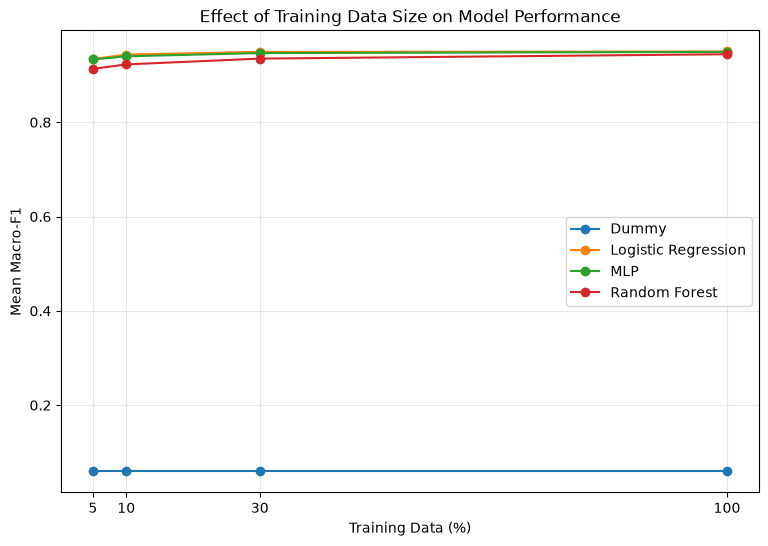

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for model_name in summary["Model"].unique():

    model_results = summary[
        summary["Model"] == model_name
    ].sort_values("Training %")

    plt.plot(
        model_results["Training %"],
        model_results["Mean_Macro_F1"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training Data (%)")
plt.ylabel("Mean Macro-F1")
plt.title("Effect of Training Data Size on Model Performance")

plt.xticks([5, 10, 30, 100])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

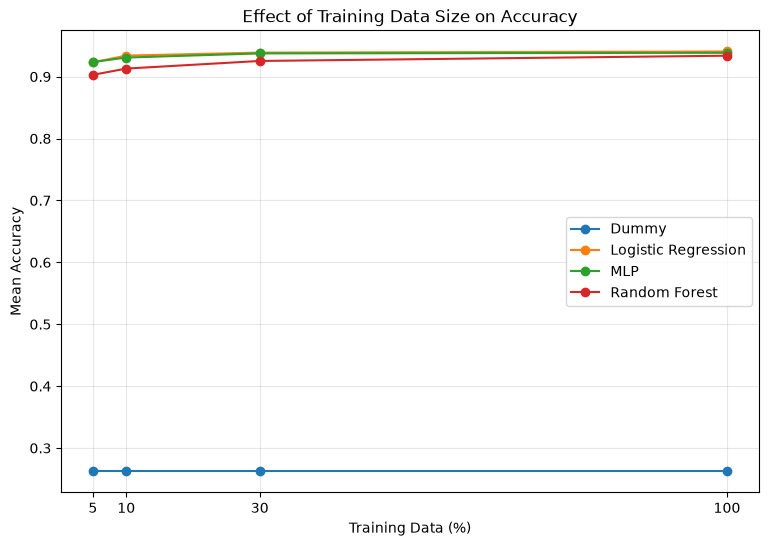

In [174]:
plt.figure(figsize=(9, 6))

for model_name in summary["Model"].unique():

    model_results = summary[
        summary["Model"] == model_name
    ].sort_values("Training %")

    plt.plot(
        model_results["Training %"],
        model_results["Mean_Accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Training Data (%)")
plt.ylabel("Mean Accuracy")
plt.title("Effect of Training Data Size on Accuracy")

plt.xticks([5, 10, 30, 100])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [175]:
# Combine original training and validation sets
X_final_train = pd.concat(
    [X_train, X_val],
    axis=0
)

y_final_train = pd.concat(
    [y_train, y_val],
    axis=0
)

print("Final training size:", X_final_train.shape)
print("Test size:", X_test.shape)

Final training size: (10834, 16)
Test size: (2709, 16)


In [176]:
final_scaler = StandardScaler()

X_final_train_scaled = final_scaler.fit_transform(
    X_final_train
)

X_test_scaled_final = final_scaler.transform(
    X_test
)

In [177]:
final_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_model.fit(
    X_final_train_scaled,
    y_final_train
)

y_test_pred = final_model.predict(
    X_test_scaled_final
)

In [178]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Macro-F1: {test_macro_f1:.4f}")

Final Test Accuracy: 0.9195
Final Test Macro-F1: 0.9306
